In [12]:
pip install pyodbc pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyodbc

In [14]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    "mssql+pyodbc://localhost\SQLEXPRESS/E_commerce_Sales?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server"
)

df = pd.read_sql("SELECT TOP 5 * FROM customers_clean", engine)
df.head()

C:\Users\jhard\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,customer_id,customer_name,gender,age,city,state,signup_date
0,0,Raghav Batta,Unknown,61,Kolkata,West Bengal,2024-01-02
1,1,Tanvi Trivedi,Unknown,51,Delhi,Delhi,2023-09-20
2,2,Mitesh Chana,Unknown,56,Jaipur,Rajasthan,2022-02-02
3,3,Lavanya Zachariah,Male,32,Lucknow,Uttar Pradesh,2025-07-14
4,4,George Ghose,Female,34,Lucknow,Uttar Pradesh,2025-09-27


In [17]:
query = """
SELECT 
    c.customer_id,
    c.gender,
    c.age,
    r.region,
    o.order_date,
    oi.quantity,
    oi.selling_price,
    oi.discount,
    oi.profit,
    p.category,
    p.sub_category
FROM customers_clean c
JOIN orders_clean o ON c.customer_id = o.customer_id
JOIN order_items_clean oi ON o.order_id = oi.order_id
JOIN products_clean p ON oi.product_id = p.product_id
LEFT JOIN regions r ON c.state = r.state
"""

df = pd.read_sql(query, engine)

In [ ]:
df.head()

In [19]:
print('The Total Numbers of Rows in the Dataset', df.shape[0])

The Total Numbers of Rows in the Dataset 1870626


In [20]:
print('The Total Numbers of Columns in the Dataset', df.shape[1])

The Total Numbers of Columns in the Dataset 11


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1870626 entries, 0 to 1870625
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   customer_id    int64  
 1   gender         object 
 2   age            object 
 3   region         object 
 4   order_date     object 
 5   quantity       int64  
 6   selling_price  float64
 7   discount       object 
 8   profit         float64
 9   category       object 
 10  sub_category   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 157.0+ MB


***Few Columns Have Wrong Data type like - Age, OrderDate, Discount***

### Identity How many null Values in the Dataset have

In [24]:
df.isnull().sum()/len(df)

customer_id      0.000000
gender           0.000000
age              0.000000
region           0.328309
order_date       0.000000
quantity         0.000000
selling_price    0.000000
discount         0.014130
profit           0.000000
category         0.000000
sub_category     0.049709
dtype: float64

### Handling Missing Values in the Dataset According to Requirment

In [26]:
df['region'] = df['region'].fillna('Unknown')
df['discount'] = df['discount'].fillna(0)
df['sub_category'] = df['sub_category'].fillna(df['sub_category'].mode()[0])

A significant number of missing values were observed in the dataset, particularly in the region column, indicating incomplete geographical mapping. To maintain data integrity, missing regions were labeled as "Unknown" instead of imputing with the most frequent value to avoid bias. Missing discount values were treated as zero, assuming no discount was applied, while sub-category values were imputed using the mode for consistent categorical analysis.

### Correcting The Datatypes

In [51]:
# Correcting OrderDate Datatypes
df['order_date'] = pd.to_datetime(df['order_date'])

In [45]:
# we couldn't change directly from object to float because in a row we have this -'20%'
df[df['discount'] == '20%'].shape

(26879, 12)

In [52]:
# Replacing '20%' with this
df['discount'] = df['discount'].replace('20%', '0.2')

In [53]:
# Checking again
df[df['discount'] == '20%'].shape

(0, 12)

In [54]:
# Correcting Discount Datatypes
df['discount'] = df['discount'].astype(float)

In [58]:
# We Have this - 'Thirty', that's why we couldn't change this directly
df[df['age'] == 'Thirty'].shape

(8913, 12)

In [60]:
# First We Will Replace this 'Thirty' with 30

df['age'] = df['age'].replace('Thirty', '30')

In [62]:
# Changing age column datatype
df['age'] = df['age'].astype(int)

### Feature Engineering 

In [65]:
# Creating Revenue Column for the Further Analysis
df['revenue'] = df['quantity'] * df['selling_price']

In [66]:
# Creating orderMonth Column for the Further Analysis

df['order_month'] = df['order_date'].dt.to_period('M')

In [67]:
# Flagging DiscountRate to Low, Mid, High to use That for Further Analysis

df['discount_level'] = pd.cut(
    df['discount'],
    bins=[0, 0.1, 0.3, 1],
    labels=['Low', 'Medium', 'High']
)

### Univariate Analysis 

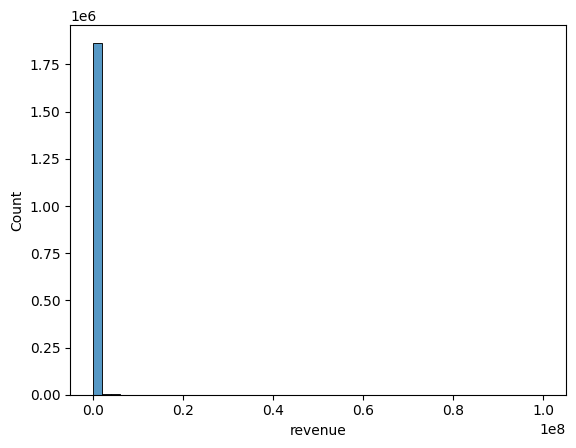

In [85]:
sns.histplot(df['revenue'], bins=50)
plt.show()

Revenue Distribution

Revenue is highly right-skewed, with most transactions generating low revenue and a few transactions contributing extremely high values, indicating the presence of outliers.

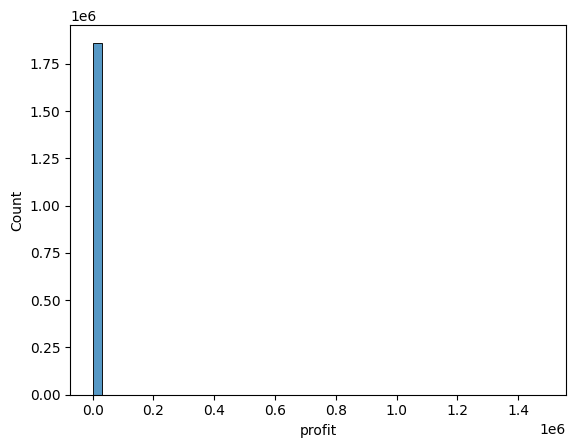

In [86]:
sns.histplot(df['profit'], bins=50)
plt.show()

Profit Distribution

Profit distribution is also right-skewed, showing that while most transactions yield low profit, a small number of transactions generate significantly higher profit.

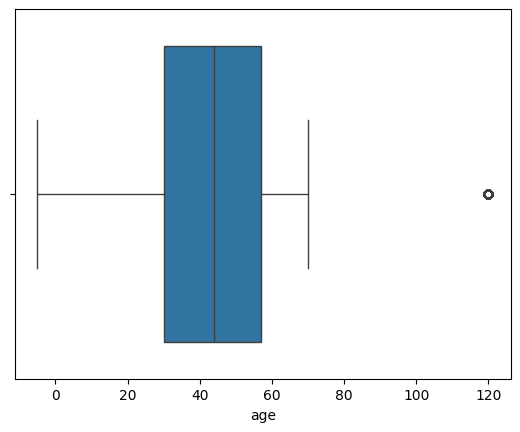

In [87]:
sns.boxplot(x=df['age'])
plt.show()

Age Distribution

Customer age is mostly concentrated between 30–60 years, with a few extreme outliers (very high or invalid ages), suggesting potential data anomalies.

### Bivariate Analysis

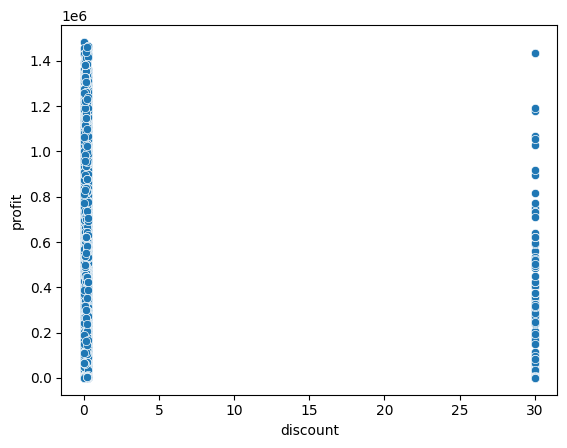

In [95]:
sns.scatterplot(x='discount', y='profit', data=df)
plt.show()

Discount vs Profit

Profit does not show a strong consistent increase with discount. Higher discount levels show wide variability in profit, indicating that heavy discounting does not guarantee higher profitability and may lead to unstable margins.

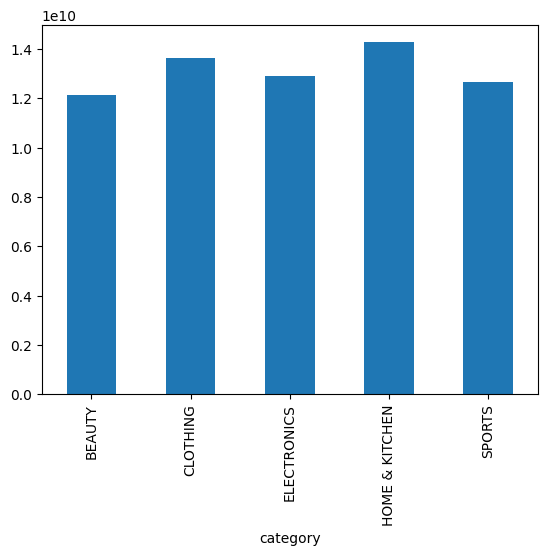

In [94]:
df.groupby('category')['revenue'].sum().plot(kind='bar')
plt.show()

Category vs Revenue

The Home & Kitchen category generates the highest revenue, followed by Clothing and Electronics, while Beauty contributes the least. This indicates strong demand concentration in specific categories

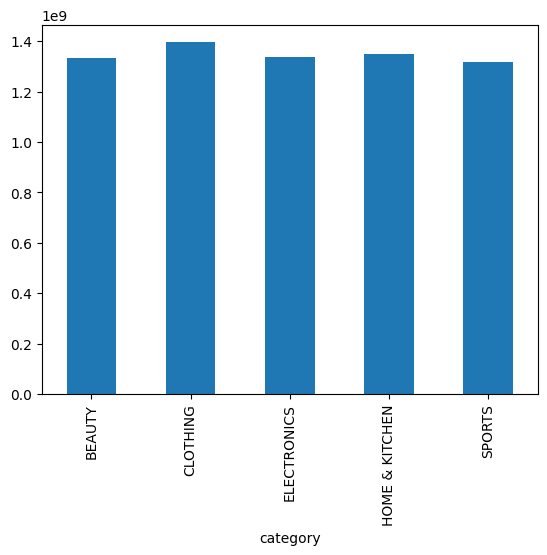

In [96]:
df.groupby('category')['profit'].sum().plot(kind='bar')
plt.show()

Category vs Profit

Profit distribution across categories is relatively similar, with Clothing slightly leading. Despite high revenue in some categories, profit differences are not proportionally high, suggesting margin variation across categories.

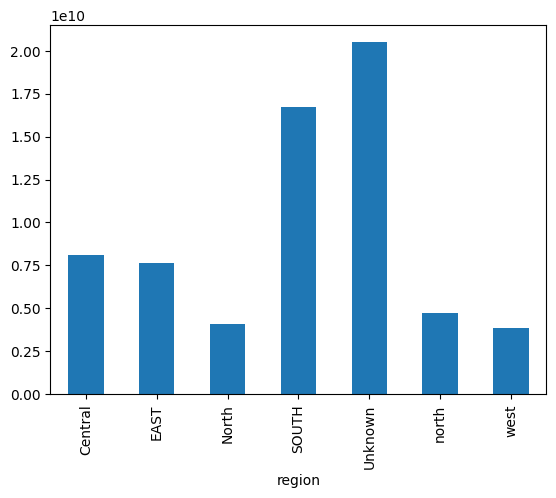

In [97]:
df.groupby('region')['revenue'].sum().plot(kind='bar')
plt.show()

Region vs Revenue

The “Unknown” region contributes the highest revenue, indicating a large portion of transactions lack proper regional mapping. Among known regions, South performs strongest, while North and West contribute comparatively less.

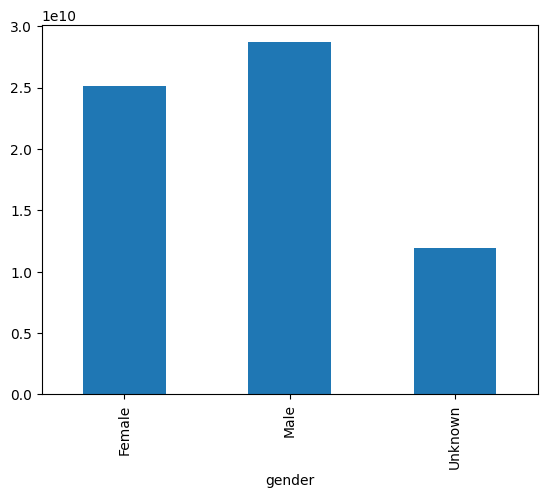

In [99]:
df.groupby('gender')['revenue'].sum().plot(kind='bar')
plt.show()

Gender vs Revenue

Male customers contribute the highest revenue, followed by Female customers, while “Unknown” gender contributes significantly less. This suggests a slightly higher purchasing contribution from male customers.

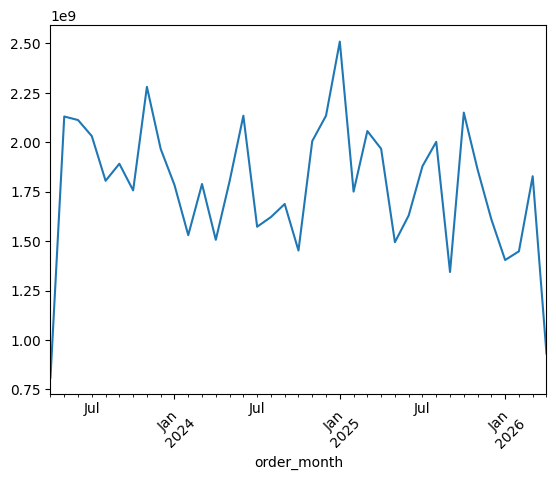

In [101]:
df.groupby('order_month')['revenue'].sum().plot()
plt.xticks(rotation=45)
plt.show()

Monthly Revenue Trend

Revenue shows fluctuating patterns over time with noticeable peaks and drops, indicating seasonality and inconsistent demand cycles rather than steady growth

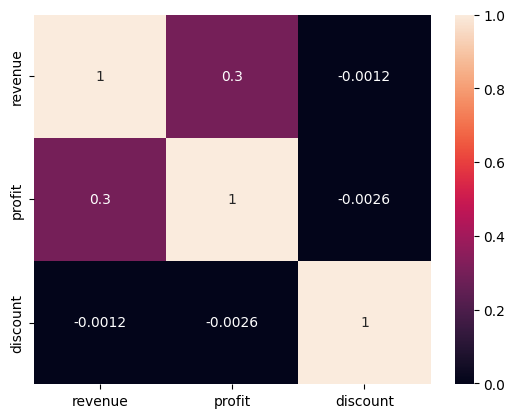

In [102]:
sns.heatmap(df[['revenue','profit','discount']].corr(), annot=True)
plt.show()

Revenue and profit have a moderate positive correlation (~0.3), meaning higher revenue generally leads to higher profit, but not strongly—there are other influencing factors (like cost or discounts).

Discount shows almost zero correlation with both revenue and profit, suggesting discounts are not significantly impacting sales or profitability in this dataset.

👉 Overall: profit is mainly driven by revenue, while discounts don’t appear to meaningfully affect either metric